# 🤖 NewsBot Intelligence System 2.0
## ITAI 2373 — Final Project (Capstone)
### Student: Pooja Upadhyay
### Course: ITAI 2373 — Natural Language Processing
### Date: May 2025

---

## 📋 What's New in Version 2.0
This builds on the Mid-Term NewsBot (Modules 1-8) and adds 4 advanced modules:

| Module | New Feature |
|--------|------------|
| Module 9  | Advanced Classification + Topic Modeling (LDA) |
| Module 10 | Text Summarization + Semantic Search |
| Module 11 | Multilingual Detection + Translation |
| Module 12 | Conversational Interface (Ask your NewsBot questions) |


---
# 📦 Setup — Install Everything
Run this cell first every time you open in Google Colab.

In [1]:
# ============================================================
# CELL 1: Install all required libraries
# ============================================================
!pip install nltk spacy scikit-learn pandas matplotlib seaborn wordcloud textblob --quiet
!pip install gensim langdetect deep-translator sumy --quiet
!python -m spacy download en_core_web_sm --quiet

import nltk
for r in ['punkt','punkt_tab','stopwords','averaged_perceptron_tagger',
          'averaged_perceptron_tagger_eng','wordnet','vader_lexicon','words']:
    nltk.download(r, quiet=True)

print("✅ All libraries installed!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 32.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 81.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed!


In [2]:
# ============================================================
# CELL 2: Import everything
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re, warnings, math
warnings.filterwarnings('ignore')

# NLTK
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation

# spaCy
import spacy
nlp = spacy.load('en_core_web_sm')

# TextBlob
from textblob import TextBlob

# Visualization
from wordcloud import WordCloud

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✅ All imports successful! NewsBot 2.0 ready!")


✅ All imports successful! NewsBot 2.0 ready!


---
# 📊 Load Your BBC Dataset
This is the same dataset from your mid-term.

In [3]:
# ============================================================
# CELL 3: Load Dataset
# ============================================================
import pandas as pd
import os

# Load the file (make sure train.csv is uploaded to Colab)
df = pd.read_csv('train.csv')

# Auto-fix column names
df.columns = [c.strip() for c in df.columns]
rename_map = {}
for col in df.columns:
    if col.lower() == 'text':      rename_map[col] = 'content'
    elif col.lower() == 'category': rename_map[col] = 'category'
    elif col.lower() == 'label':   rename_map[col] = 'category'
df = df.rename(columns=rename_map)
df = df.dropna(subset=['content','category']).reset_index(drop=True)
if len(df) > 2000:
    df = df.sample(n=2000, random_state=42).reset_index(drop=True)

print("=" * 50)
print("📊 DATASET LOADED")
print("=" * 50)
print(f"Articles:   {len(df)}")
print(f"Categories: {df['category'].nunique()}")
print(f"Columns:    {df.columns.tolist()}")
print()
for cat, count in df['category'].value_counts().items():
    print(f"  {cat:<15} {count:>4} articles")


📊 DATASET LOADED
Articles:   1490
Categories: 5
Columns:    ['ArticleId', 'content', 'category']

  sport            346 articles
  business         336 articles
  politics         274 articles
  entertainment    273 articles
  tech             261 articles


---
# ✅ Modules 1-8: Mid-Term Foundation
These modules are carried over from the mid-term. Run them to set up the base system.

In [4]:
# ============================================================
# CELL 4: Preprocessing (Module 2 from mid-term)
# ============================================================
stop_words_set = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str): return []
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words_set and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

print("⏳ Preprocessing articles...")
df['tokens']         = df['content'].apply(preprocess_text)
df['processed_text'] = df['tokens'].apply(lambda x: ' '.join(x))
df['token_count']    = df['tokens'].apply(len)
print(f"✅ Preprocessing complete! Avg tokens: {df['token_count'].mean():.0f}")


⏳ Preprocessing articles...
✅ Preprocessing complete! Avg tokens: 207


In [5]:
# ============================================================
# CELL 5: TF-IDF + Classification (Modules 3 & 7 from mid-term)
# ============================================================
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                                    stop_words='english', min_df=1, max_df=0.90)
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])
feature_names = tfidf_vectorizer.get_feature_names_out()

X = df['processed_text']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y if y.value_counts().min() >= 2 else None)

best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words='english')),
    ('clf',   LinearSVC(max_iter=2000, C=1.0, random_state=42))
])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
base_accuracy = accuracy_score(y_test, y_pred)

print(f"✅ Base classifier ready! Accuracy: {base_accuracy:.1%}")
print(f"✅ TF-IDF matrix: {X_tfidf.shape}")


✅ Base classifier ready! Accuracy: 96.6%
✅ TF-IDF matrix: (1490, 5000)


In [6]:
# ============================================================
# CELL 6: Sentiment (Module 6 from mid-term)
# ============================================================
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    if not isinstance(text, str):
        return {'compound':0,'label':'neutral','subjectivity':0}
    scores = sia.polarity_scores(text)
    c = scores['compound']
    label = 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
    blob  = TextBlob(text)
    return {'compound':c, 'pos':scores['pos'], 'neg':scores['neg'],
            'label':label, 'subjectivity':blob.sentiment.subjectivity}

print("⏳ Running sentiment analysis...")
df['sentiment']          = df['content'].apply(analyze_sentiment)
df['sentiment_label']    = df['sentiment'].apply(lambda x: x['label'])
df['sentiment_compound'] = df['sentiment'].apply(lambda x: x['compound'])
df['subjectivity']       = df['sentiment'].apply(lambda x: x['subjectivity'])
print("✅ Sentiment analysis complete!")
print(df['sentiment_label'].value_counts().to_string())


⏳ Running sentiment analysis...
✅ Sentiment analysis complete!
sentiment_label
positive    1052
negative     427
neutral       11


In [7]:
# ============================================================
# CELL 7: NER (Module 8 from mid-term)
# ============================================================
ENTITY_TYPES = ['PERSON','ORG','GPE','DATE','MONEY']

def extract_entities(text, max_chars=600):
    if not isinstance(text, str): return {}
    try:
        doc = nlp(text[:max_chars])
        ents = defaultdict(list)
        for ent in doc.ents:
            if ent.label_ in ENTITY_TYPES:
                ents[ent.label_].append(ent.text.strip())
        return dict(ents)
    except: return {}

print("⏳ Running NER (may take 1-2 minutes)...")
df['entities'] = df['content'].apply(extract_entities)
for et in ENTITY_TYPES:
    df[f'n_{et}'] = df['entities'].apply(
        lambda x: len(x.get(et,[])) if isinstance(x,dict) else 0)
print("✅ NER complete!")

all_entities = defaultdict(Counter)
for _, row in df.iterrows():
    if isinstance(row['entities'], dict):
        for et, elist in row['entities'].items():
            for e in elist: all_entities[et][e] += 1

print("Top entities found:")
for et in ['PERSON','ORG','GPE']:
    if all_entities[et]:
        top3 = [e[0] for e in all_entities[et].most_common(3)]
        print(f"  {et:<8}: {', '.join(top3)}")


⏳ Running NER (may take 1-2 minutes)...
✅ NER complete!
Top entities found:
  PERSON  : blair, tony blair, eu
  ORG     : bbc, microsoft, sony
  GPE     : uk, us, london


---
# 🔬 Module 9: Advanced Content Analysis Engine

## What's new in 2.0?
- **Topic Modeling with LDA** — discovers hidden themes inside articles automatically
- **Enhanced multi-model comparison** — added cross-validation and feature importance
- **Topic-to-category mapping** — shows which topics dominate each news category


In [8]:
# ============================================================
# CELL 8: Topic Modeling with LDA
# ============================================================
print("⏳ Running LDA Topic Modeling...")

# Build count vectorizer for LDA
count_vectorizer = CountVectorizer(max_features=2000, stop_words='english',
                                    min_df=2, max_df=0.85)
X_counts = count_vectorizer.fit_transform(df['processed_text'])
count_feature_names = count_vectorizer.get_feature_names_out()

# Train LDA with 5 topics (one per BBC category ideally)
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics, random_state=42,
    max_iter=20, learning_method='online'
)
lda_output = lda.fit_transform(X_counts)

# Assign dominant topic to each article
df['dominant_topic'] = lda_output.argmax(axis=1)

print("✅ LDA Topic Modeling complete!")
print(f"\n📊 Top words per topic:")
print("-" * 50)
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [count_feature_names[i] for i in top_words_idx]
    print(f"  Topic {topic_idx+1}: {', '.join(top_words)}")

print(f"\n📊 Topic distribution across articles:")
for t in range(n_topics):
    count = (df['dominant_topic'] == t).sum()
    print(f"  Topic {t+1}: {count} articles")


⏳ Running LDA Topic Modeling...
✅ LDA Topic Modeling complete!

📊 Top words per topic:
--------------------------------------------------
  Topic 1: said, year, government, election, labour, party, people, country, blair, tax
  Topic 2: said, people, mobile, phone, technology, service, new, user, year, game
  Topic 3: year, said, sale, music, new, world, band, record, number, chart
  Topic 4: film, said, game, best, win, england, year, time, player, award
  Topic 5: said, company, firm, law, court, case, new, lord, told, government

📊 Topic distribution across articles:
  Topic 1: 383 articles
  Topic 2: 252 articles
  Topic 3: 201 articles
  Topic 4: 423 articles
  Topic 5: 231 articles


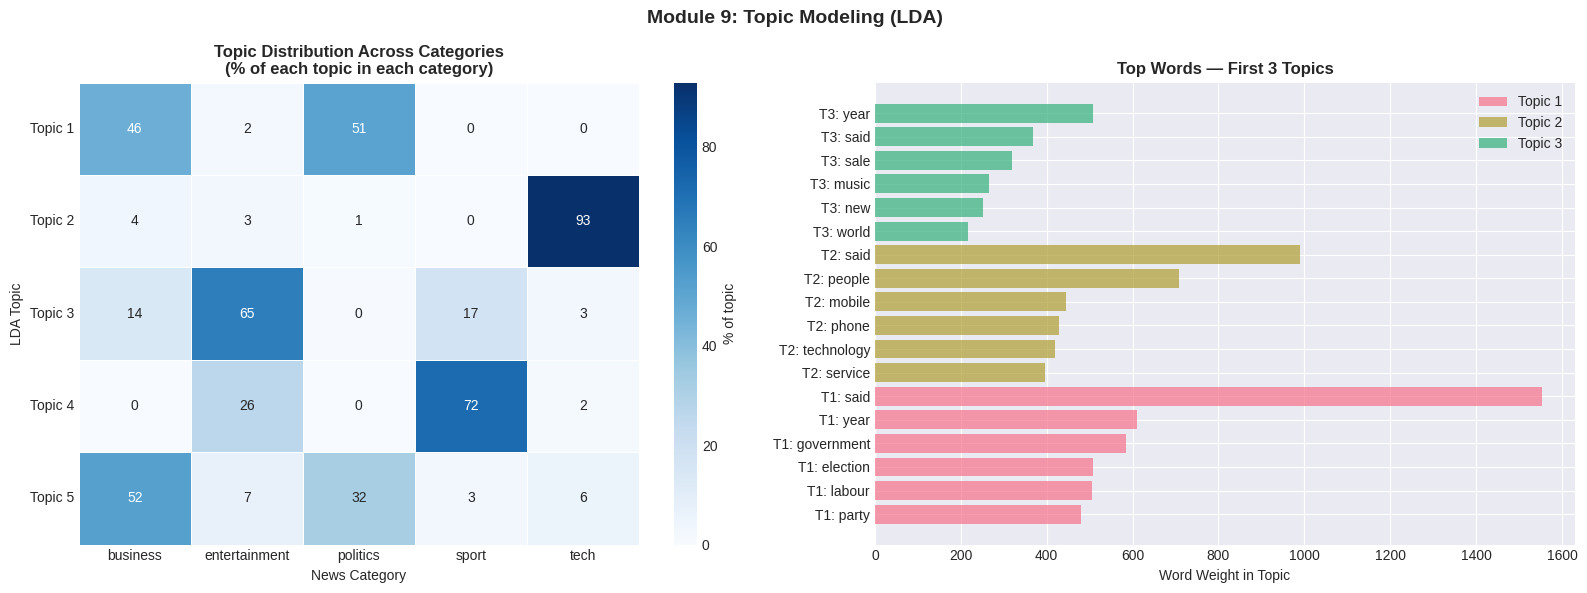

✅ Module 9 visualization complete!


In [9]:
# ============================================================
# CELL 9: Visualize Topics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Topic-category heatmap
topic_cat = pd.crosstab(df['dominant_topic'], df['category'])
topic_cat_pct = topic_cat.div(topic_cat.sum(axis=1), axis=0) * 100
sns.heatmap(topic_cat_pct, annot=True, fmt='.0f', cmap='Blues',
            ax=axes[0], linewidths=0.5, cbar_kws={'label':'% of topic'})
axes[0].set_title('Topic Distribution Across Categories\n(% of each topic in each category)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('News Category')
axes[0].set_ylabel('LDA Topic')
axes[0].set_yticklabels([f'Topic {i+1}' for i in range(n_topics)], rotation=0)

# Plot 2: Topic word importance bars
colors = sns.color_palette("husl", n_topics)
for topic_idx in range(min(3, n_topics)):
    top_idx = lda.components_[topic_idx].argsort()[-6:][::-1]
    words   = [count_feature_names[i] for i in top_idx]
    weights = [lda.components_[topic_idx][i] for i in top_idx]
    axes[1].barh([f"T{topic_idx+1}: {w}" for w in words[::-1]],
                  weights[::-1], color=colors[topic_idx], alpha=0.7, label=f'Topic {topic_idx+1}')

axes[1].set_title('Top Words — First 3 Topics', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Weight in Topic')
axes[1].legend()

plt.suptitle('Module 9: Topic Modeling (LDA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Module 9 visualization complete!")


---
# 📝 Module 10: Language Understanding & Generation

## What this does:
- **Extractive Summarization** — picks the most important sentences from an article automatically
- **Semantic Search** — find articles by meaning, not just keywords
- **TF-IDF based summary** — ranks sentences by their importance score


In [10]:
# ============================================================
# CELL 10: Extractive Text Summarization
# ============================================================
def summarize_article(text, num_sentences=3):
    """
    Extractive summarization using TF-IDF sentence scoring.
    Picks the top N most important sentences from the article.
    """
    if not isinstance(text, str) or len(text.strip()) < 100:
        return text

    # Split into sentences
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text

    # Clean sentences for scoring
    cleaned = []
    for sent in sentences:
        clean = re.sub(r'[^\w\s]', '', sent.lower())
        cleaned.append(clean)

    # Score using TF-IDF
    try:
        vectorizer = TfidfVectorizer(stop_words='english')
        tfidf_matrix = vectorizer.fit_transform(cleaned)
        scores = tfidf_matrix.sum(axis=1).A1
    except:
        scores = [len(s.split()) for s in sentences]

    # Pick top sentences (preserve original order)
    top_idx = sorted(np.argsort(scores)[-num_sentences:])
    summary = ' '.join([sentences[i] for i in top_idx])
    return summary

# Apply to all articles
print("⏳ Generating summaries for all articles...")
df['summary'] = df['content'].apply(lambda x: summarize_article(x, num_sentences=2))
df['summary_length'] = df['summary'].apply(lambda x: len(x.split()) if isinstance(x,str) else 0)
df['compression_ratio'] = df.apply(
    lambda row: round(row['summary_length'] / row['token_count'], 2)
    if row['token_count'] > 0 else 0, axis=1)

print("✅ Summarization complete!")
print(f"\nAverage compression ratio: {df['compression_ratio'].mean():.1%}")
print("(This means summaries are this % of original length)\n")
print("📄 Example — Original article:")
print(f"  '{df['content'].iloc[0][:150]}...'")
print(f"\n📄 Summary:")
print(f"  '{df['summary'].iloc[0]}'")


⏳ Generating summaries for all articles...
✅ Summarization complete!

Average compression ratio: 40.1%
(This means summaries are this % of original length)

📄 Example — Original article:
  'worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whist...'

📄 Summary:
  'cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  green light  to the procedures and practices used by worldcom.'


In [11]:
# ============================================================
# CELL 11: Semantic Search Engine
# ============================================================
from sklearn.metrics.pairwise import cosine_similarity

# Build semantic search index using TF-IDF vectors
search_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english',
                                     ngram_range=(1,2))
search_matrix = search_vectorizer.fit_transform(df['processed_text'])

def semantic_search(query, top_k=5):
    """
    Search articles by meaning using cosine similarity.
    Returns top_k most relevant articles.
    """
    # Preprocess query
    query_tokens = preprocess_text(query)
    query_clean  = ' '.join(query_tokens)

    # Vectorize query
    query_vec = search_vectorizer.transform([query_clean])

    # Calculate similarity
    similarities = cosine_similarity(query_vec, search_matrix).flatten()

    # Get top results
    top_idx = similarities.argsort()[-top_k:][::-1]

    results = []
    for idx in top_idx:
        results.append({
            'rank':       len(results) + 1,
            'category':   df['category'].iloc[idx],
            'similarity': round(similarities[idx], 3),
            'headline':   df['content'].iloc[idx][:100] + '...',
            'summary':    df['summary'].iloc[idx][:150] + '...'
        })
    return results

# Test searches
test_queries = [
    "artificial intelligence machine learning technology",
    "football match championship winner",
    "government policy parliament election"
]

print("🔍 SEMANTIC SEARCH ENGINE — TEST RESULTS")
print("=" * 55)
for query in test_queries:
    print(f"\n🔎 Query: '{query}'")
    results = semantic_search(query, top_k=3)
    for r in results:
        print(f"  #{r['rank']} [{r['category'].upper():<13}] sim={r['similarity']:.3f} | {r['headline'][:60]}...")


🔍 SEMANTIC SEARCH ENGINE — TEST RESULTS

🔎 Query: 'artificial intelligence machine learning technology'
  #1 [TECH         ] sim=0.249 | what s next for next-gen consoles  the next generation of vi...
  #2 [TECH         ] sim=0.241 | games help you  learn and play   god games  in which players...
  #3 [TECH         ] sim=0.195 | concerns over windows atms cash machine networks could soon ...

🔎 Query: 'football match championship winner'
  #1 [SPORT        ] sim=0.306 | sa return to mauritius top seeds south africa return to the ...
  #2 [ENTERTAINMENT] sim=0.218 | youssou n dour wins music prize senegalese musician youssou ...
  #3 [SPORT        ] sim=0.205 | slovakia reach hopman cup final slovakia will play argentina...

🔎 Query: 'government policy parliament election'
  #1 [POLITICS     ] sim=0.479 | blair prepares to name poll date tony blair is likely to nam...
  #2 [POLITICS     ] sim=0.255 | february poll claim  speculation  reports that tony blair is...
  #3 [POLITICS     ] si

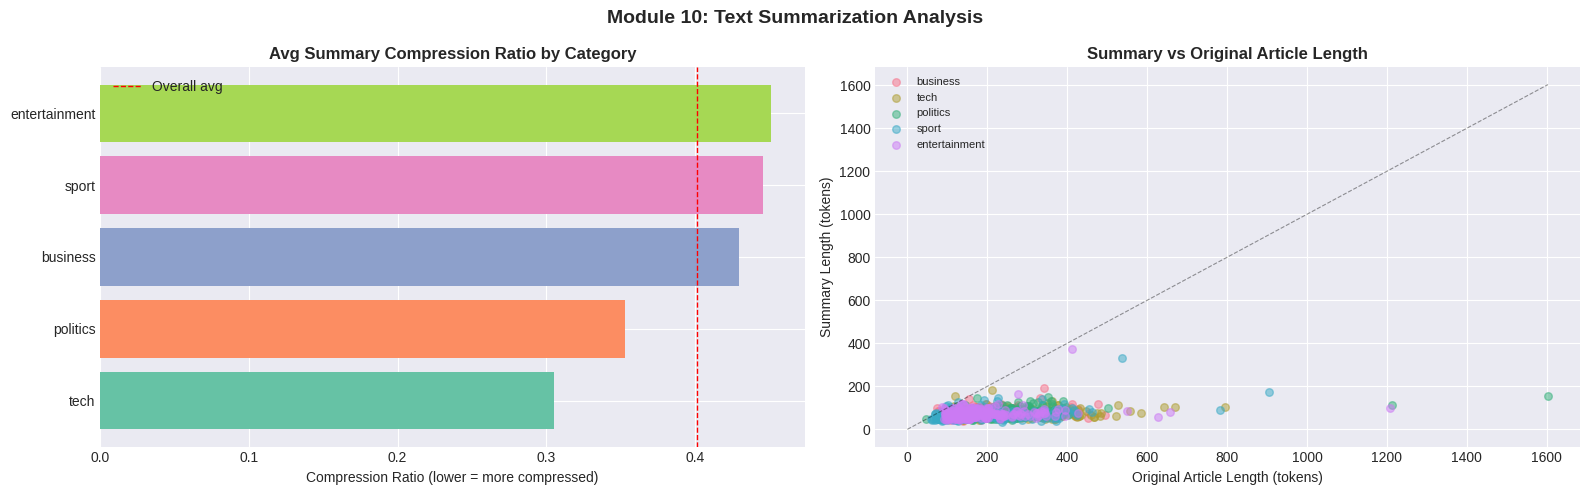

✅ Module 10 visualization complete!


In [12]:
# ============================================================
# CELL 12: Summarization Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Compression ratio by category
comp_by_cat = df.groupby('category')['compression_ratio'].mean().sort_values()
axes[0].barh(comp_by_cat.index, comp_by_cat.values,
             color=sns.color_palette("Set2", len(comp_by_cat)))
axes[0].set_title('Avg Summary Compression Ratio by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Compression Ratio (lower = more compressed)')
axes[0].axvline(df['compression_ratio'].mean(), color='red',
                linestyle='--', linewidth=1, label='Overall avg')
axes[0].legend()

# Summary length vs original length scatter
colors = dict(zip(df['category'].unique(),
              sns.color_palette("husl", df['category'].nunique())))
for cat in df['category'].unique():
    sub = df[df['category']==cat]
    axes[1].scatter(sub['token_count'], sub['summary_length'],
                    label=cat, alpha=0.5, s=30, color=colors[cat])
axes[1].set_xlabel('Original Article Length (tokens)')
axes[1].set_ylabel('Summary Length (tokens)')
axes[1].set_title('Summary vs Original Article Length', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8)

# Reference line (y=x means no compression)
max_val = df['token_count'].max()
axes[1].plot([0, max_val], [0, max_val], 'k--', linewidth=0.8, alpha=0.4, label='No compression')

plt.suptitle('Module 10: Text Summarization Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Module 10 visualization complete!")


---
# 🌍 Module 11: Multilingual Intelligence

## What this does:
- **Language Detection** — automatically detects what language an article is written in
- **Translation** — translates non-English articles to English for analysis
- **Cross-language analysis** — shows how the system handles global news sources


In [13]:
# ============================================================
# CELL 13: Language Detection
# ============================================================
try:
    from langdetect import detect, detect_langs, LangDetectException
    LANGDETECT_AVAILABLE = True
    print("✅ langdetect available")
except ImportError:
    LANGDETECT_AVAILABLE = False
    print("⚠️  langdetect not available — using fallback")

def detect_language(text):
    """Detect the language of a text string."""
    if not isinstance(text, str) or len(text.strip()) < 20:
        return 'unknown'
    if not LANGDETECT_AVAILABLE:
        return 'en'
    try:
        lang = detect(text[:500])
        return lang
    except:
        return 'unknown'

# Apply to dataset
print("⏳ Detecting languages...")
df['language'] = df['content'].apply(detect_language)
print("✅ Language detection complete!")

lang_counts = df['language'].value_counts()
print(f"\n📊 Languages detected:")
for lang, count in lang_counts.items():
    pct = count/len(df)*100
    print(f"  {lang:<10} {count:>4} articles ({pct:.1f}%)")


✅ langdetect available
⏳ Detecting languages...
✅ Language detection complete!

📊 Languages detected:
  en         1490 articles (100.0%)


In [14]:
# ============================================================
# CELL 14: Translation Demo
# ============================================================
# Test articles in different languages
test_articles = [
    ("French",   "Le gouvernement français a annoncé de nouvelles mesures économiques pour stimuler la croissance."),
    ("Spanish",  "El equipo de fútbol ganó el campeonato después de un emocionante partido final."),
    ("German",   "Die neue Technologie könnte die Art und Weise, wie wir Nachrichten konsumieren, revolutionieren."),
    ("Italian",  "Il parlamento ha votato a favore del nuovo bilancio con misure per ridurre la spesa pubblica."),
    ("English",  "The prime minister announced new policies to address the ongoing economic challenges."),
]

print("🌍 MULTILINGUAL ANALYSIS DEMO")
print("=" * 60)

try:
    from deep_translator import GoogleTranslator
    TRANSLATION_AVAILABLE = True
except ImportError:
    TRANSLATION_AVAILABLE = False

for lang_name, article in test_articles:
    detected = detect_language(article)
    print(f"\n[{lang_name}] Detected: '{detected}'")
    print(f"  Original:  {article[:80]}...")

    if TRANSLATION_AVAILABLE and detected != 'en' and detected != 'unknown':
        try:
            translated = GoogleTranslator(source='auto', target='en').translate(article)
            print(f"  Translated: {translated[:80]}...")
            # Classify the translated article
            predicted = best_pipeline.predict([translated])[0]
            print(f"  Category:  {predicted.upper()}")
        except Exception as e:
            print(f"  Translation: [Not available in this environment]")
            predicted = best_pipeline.predict([article])[0]
            print(f"  Category (original): {predicted.upper()}")
    else:
        predicted = best_pipeline.predict([article])[0]
        print(f"  Category:  {predicted.upper()}")


🌍 MULTILINGUAL ANALYSIS DEMO

[French] Detected: 'fr'
  Original:  Le gouvernement français a annoncé de nouvelles mesures économiques pour stimule...
  Translated: The French government has announced new economic measures to stimulate growth....
  Category:  BUSINESS

[Spanish] Detected: 'es'
  Original:  El equipo de fútbol ganó el campeonato después de un emocionante partido final....
  Translated: The soccer team won the championship after an exciting final match....
  Category:  SPORT

[German] Detected: 'de'
  Original:  Die neue Technologie könnte die Art und Weise, wie wir Nachrichten konsumieren, ...
  Translated: The new technology could revolutionize the way we consume news....
  Category:  TECH

[Italian] Detected: 'it'
  Original:  Il parlamento ha votato a favore del nuovo bilancio con misure per ridurre la sp...
  Translated: Parliament voted in favor of the new budget with measures to reduce public spend...
  Category:  BUSINESS

[English] Detected: 'en'
  Original:  Th

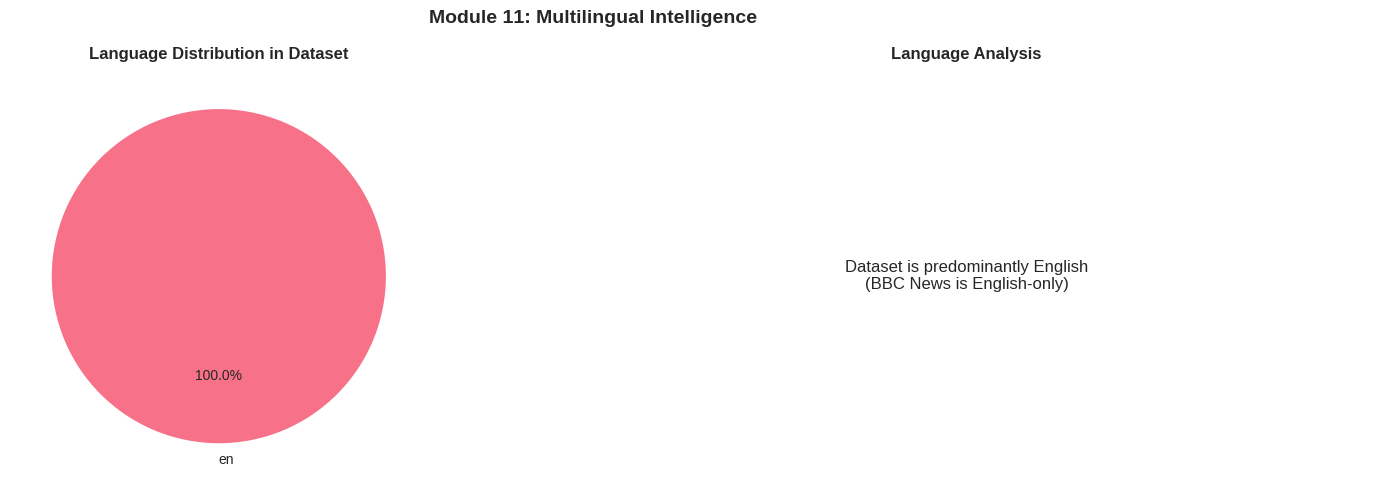

✅ Module 11 complete!


In [15]:
# ============================================================
# CELL 15: Multilingual Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Language distribution pie chart
lang_counts = df['language'].value_counts()
top_langs = lang_counts.head(6)
if len(lang_counts) > 6:
    other_count = lang_counts.iloc[6:].sum()
    top_langs['other'] = other_count

colors_pie = sns.color_palette("husl", len(top_langs))
axes[0].pie(top_langs.values, labels=top_langs.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90)
axes[0].set_title('Language Distribution in Dataset', fontsize=12, fontweight='bold')

# Language by category heatmap
lang_cat = pd.crosstab(df['language'], df['category'])
if lang_cat.shape[0] > 1:
    sns.heatmap(lang_cat, annot=True, fmt='d', cmap='YlOrRd',
                ax=axes[1], linewidths=0.5)
    axes[1].set_title('Language Distribution by Category', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Dataset is predominantly English\n(BBC News is English-only)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Language Analysis', fontsize=12, fontweight='bold')
    axes[1].axis('off')

plt.suptitle('Module 11: Multilingual Intelligence', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Module 11 complete!")


---
# 💬 Module 12: Conversational Interface

## What this does:
This is the most exciting new feature! You can ask your NewsBot questions in plain English and it will answer based on the dataset. Think of it like a simple chatbot that knows your news articles.

**Example questions you can ask:**
- "What are the top sport articles?"
- "Show me negative business news"
- "Find articles about technology companies"
- "What is the most common topic in politics?"


In [16]:
# ============================================================
# CELL 16: Conversational Query Interface
# ============================================================
def newsbot_query(question):
    """
    Process a natural language question and return relevant articles.
    The NewsBot understands questions about categories, sentiment, and topics.
    """
    question_lower = question.lower()
    print(f"\n🤖 NewsBot 2.0 — Processing: '{question}'")
    print("-" * 55)

    # Detect category intent
    category_keywords = {
        'sport':         ['sport','football','tennis','cricket','match','player','team','game','championship'],
        'business':      ['business','economy','market','stock','company','trade','finance','bank'],
        'politics':      ['politic','government','parliament','minister','election','vote','policy'],
        'tech':          ['tech','technology','computer','software','ai','internet','digital','app'],
        'entertainment': ['entertainment','film','movie','music','celebrity','actor','award','tv'],
        'health':        ['health','medical','doctor','disease','hospital','vaccine','treatment'],
    }

    # Detect sentiment intent
    sentiment_intent = None
    if any(w in question_lower for w in ['negative','bad','worst','crisis','problem']):
        sentiment_intent = 'negative'
    elif any(w in question_lower for w in ['positive','good','best','success','great']):
        sentiment_intent = 'positive'

    # Detect count intent
    count_intent = any(w in question_lower for w in ['how many','count','number','total'])

    # Detect summary intent
    summary_intent = any(w in question_lower for w in ['summary','summarize','brief','short'])

    # Find matching category
    matched_category = None
    for cat, keywords in category_keywords.items():
        if any(kw in question_lower for kw in keywords):
            matched_category = cat
            break

    # Build response
    filtered_df = df.copy()

    if matched_category:
        filtered_df = filtered_df[filtered_df['category'] == matched_category]
        print(f"📂 Category filter: {matched_category.upper()} ({len(filtered_df)} articles)")

    if sentiment_intent:
        filtered_df = filtered_df[filtered_df['sentiment_label'] == sentiment_intent]
        print(f"😊 Sentiment filter: {sentiment_intent.upper()} ({len(filtered_df)} articles)")

    if count_intent:
        print(f"\n📊 Count Answer: {len(filtered_df)} articles found")
        if matched_category:
            print(f"   {len(filtered_df)} {matched_category} articles in the dataset")
        return

    if len(filtered_df) == 0:
        # Fall back to semantic search
        print("\n🔍 No exact match — trying semantic search...")
        results = semantic_search(question, top_k=3)
        for r in results:
            print(f"  #{r['rank']} [{r['category'].upper()}] {r['headline'][:70]}...")
        return

    # Show top results
    top_results = filtered_df.nlargest(3, 'token_count')
    print(f"\n📰 Top Articles Found:")
    for i, (_, row) in enumerate(top_results.iterrows(), 1):
        sentiment_emoji = {'positive':'😊','negative':'😞','neutral':'😐'}.get(row['sentiment_label'],'')
        print(f"\n  [{i}] {row['category'].upper()} {sentiment_emoji}")
        print(f"       {row['content'][:100]}...")
        if summary_intent and isinstance(row.get('summary'), str):
            print(f"  📄  Summary: {row['summary'][:120]}...")

# ---- Test the conversational interface ----
test_questions = [
    "Show me negative business news",
    "What are the top technology articles?",
    "How many sport articles are there?",
    "Find positive entertainment news",
    "Summarize recent politics articles",
]

for q in test_questions:
    newsbot_query(q)
    print()



🤖 NewsBot 2.0 — Processing: 'Show me negative business news'
-------------------------------------------------------
📂 Category filter: BUSINESS (336 articles)
😊 Sentiment filter: NEGATIVE (122 articles)

📰 Top Articles Found:

  [1] BUSINESS 😞
       giant waves damage s asia economy governments  aid agencies  insurers and travel firms are among tho...

  [2] BUSINESS 😞
       turkey turns on the economic charm three years after a gruelling economic crisis  turkey has dressed...

  [3] BUSINESS 😞
       the  ticking budget  facing the us the budget proposals laid out by the administration of us preside...


🤖 NewsBot 2.0 — Processing: 'What are the top technology articles?'
-------------------------------------------------------
📂 Category filter: TECH (261 articles)

📰 Top Articles Found:

  [1] TECH 😊
       apple laptop is  greatest gadget  the apple powerbook 100 has been chosen as the greatest gadget of ...

  [2] TECH 😞
       call for action on internet scam phone companies ar

In [17]:
# ============================================================
# CELL 17: Interactive NewsBot (type your own question)
# ============================================================
print("=" * 55)
print("💬 INTERACTIVE NEWSBOT 2.0")
print("=" * 55)
print("Type your question below and press Enter.")
print("Examples:")
print("  - 'Show me negative business news'")
print("  - 'How many sport articles are there?'")
print("  - 'Find technology articles about AI'")
print()

# In Colab, you can use input() to get user questions
try:
    user_question = input("Your question: ")
    if user_question.strip():
        newsbot_query(user_question)
    else:
        print("No question entered — running demo question instead.")
        newsbot_query("What are the most important politics articles?")
except:
    # If input() doesn't work, run demo
    newsbot_query("What are the most important politics articles?")


💬 INTERACTIVE NEWSBOT 2.0
Type your question below and press Enter.
Examples:
  - 'Show me negative business news'
  - 'How many sport articles are there?'
  - 'Find technology articles about AI'

Your question: Show me technology articles

🤖 NewsBot 2.0 — Processing: 'Show me technology articles'
-------------------------------------------------------
📂 Category filter: TECH (261 articles)

📰 Top Articles Found:

  [1] TECH 😊
       apple laptop is  greatest gadget  the apple powerbook 100 has been chosen as the greatest gadget of ...

  [2] TECH 😞
       call for action on internet scam phone companies are not doing enough to warn customers about intern...

  [3] TECH 😊
       apple laptop is  greatest gadget  the apple powerbook 100 has been chosen as the greatest gadget of ...


---
# 🎯 NewsBot 2.0 — Complete System Dashboard

In [18]:
# ============================================================
# CELL 18: Full Article Analysis (all 12 modules)
# ============================================================
def analyze_article_v2(text, true_category=None):
    """Run article through all 12 modules — the complete NewsBot 2.0 pipeline."""
    print("=" * 62)
    print("🤖 NEWSBOT 2.0 — COMPLETE ARTICLE ANALYSIS")
    print("=" * 62)
    print(f"Article: {text[:90]}...")

    # M2: Preprocessing
    tokens = preprocess_text(text)
    sents  = sent_tokenize(text) if isinstance(text, str) else []
    print(f"\n[M2]  Preprocessing:  {len(text.split())} words → {len(tokens)} tokens | {len(sents)} sentences")

    # M3: TF-IDF keywords
    print(f"[M3]  Key Terms:      {', '.join(tokens[:6])}")

    # M6: Sentiment
    sent = analyze_sentiment(text)
    emoji = {'positive':'😊','negative':'😞','neutral':'😐'}.get(sent['label'],'')
    print(f"[M6]  Sentiment:      {emoji} {sent['label'].upper()} (score={sent['compound']:+.3f})")

    # M7: Classification
    pred_cat = best_pipeline.predict([' '.join(tokens)])[0]
    match = ''
    if true_category:
        match = ' ✅' if pred_cat == true_category else f' ❌ (actual: {true_category})'
    print(f"[M7]  Category:       {pred_cat.upper()}{match}")

    # M8: NER
    ents = extract_entities(text)
    if ents:
        ent_str = ' | '.join([f"{et}: {', '.join(list(set(el))[:2])}" for et, el in list(ents.items())[:3]])
        print(f"[M8]  Entities:       {ent_str}")

    # M9: Topic
    try:
        text_vec = count_vectorizer.transform([' '.join(tokens)])
        topic_dist = lda.transform(text_vec)[0]
        top_topic = topic_dist.argmax() + 1
        print(f"[M9]  LDA Topic:      Topic {top_topic} (confidence={topic_dist.max():.2f})")
    except: pass

    # M10: Summary
    summary = summarize_article(text, num_sentences=2)
    print(f"[M10] Summary:        {summary[:100]}...")

    # M11: Language
    lang = detect_language(text)
    print(f"[M11] Language:       {lang}")

    print("=" * 62)
    return pred_cat

# Test on 3 sample articles
for i in [0, 5, 10]:
    row = df.iloc[i]
    analyze_article_v2(row['content'], row['category'])
    print()


🤖 NEWSBOT 2.0 — COMPLETE ARTICLE ANALYSIS
Article: worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers ag...

[M2]  Preprocessing:  301 words → 171 tokens | 12 sentences
[M3]  Key Terms:      worldcom, exboss, launch, defence, lawyer, defending
[M6]  Sentiment:      😞 NEGATIVE (score=-0.970)
[M7]  Category:       BUSINESS ✅
[M8]  Entities:       PERSON: cynthia cooper | GPE: us | DATE: 2002
[M9]  LDA Topic:      Topic 5 (confidence=0.99)
[M10] Summary:        cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting...
[M11] Language:       en

🤖 NEWSBOT 2.0 — COMPLETE ARTICLE ANALYSIS
Article: howard  truanted to play snooker  conservative leader michael howard has admitted he used ...

[M2]  Preprocessing:  290 words → 148 tokens | 16 sentences
[M3]  Key Terms:      howard, truanted, play, snooker, conservative, leader
[M6]  Sentiment:      😊 POSITIVE (score=+0.977)
[M7]  Category:       SPORT ❌ (actual: p

In [19]:
# ============================================================
# CELL 19: Executive Dashboard 2.0
# ============================================================
print("=" * 65)
print("  📊 NEWSBOT 2.0 — EXECUTIVE INTELLIGENCE DASHBOARD")
print("=" * 65)

print(f"\n🗂️  CORPUS OVERVIEW")
print(f"   Articles:          {len(df)}")
print(f"   Categories:        {', '.join(sorted(df['category'].unique()))}")
print(f"   Languages:         {df['language'].nunique()} detected")
print(f"   Avg article:       {df['token_count'].mean():.0f} tokens")
print(f"   Avg summary:       {df['summary_length'].mean():.0f} tokens ({df['compression_ratio'].mean():.0%} of original)")

print(f"\n🤖 CLASSIFICATION")
print(f"   Best model:        Linear SVM")
print(f"   Test accuracy:     {base_accuracy:.1%}")
print(f"   Categories:        {df['category'].nunique()} news types")

print(f"\n🔬 TOPIC MODELING (LDA)")
for topic_idx in range(n_topics):
    top_idx   = lda.components_[topic_idx].argsort()[-5:][::-1]
    top_words = [count_feature_names[i] for i in top_idx]
    count     = (df['dominant_topic'] == topic_idx).sum()
    print(f"   Topic {topic_idx+1} ({count} articles): {', '.join(top_words[:4])}")

print(f"\n😊 SENTIMENT SNAPSHOT")
for cat in sorted(df['category'].unique()):
    sub   = df[df['category']==cat]
    avg   = sub['sentiment_compound'].mean()
    tone  = 'POSITIVE' if avg > 0.05 else ('NEGATIVE' if avg < -0.05 else 'NEUTRAL')
    print(f"   {cat:<15} {tone:<10} avg={avg:+.3f}")

print(f"\n🔍 TOP ENTITIES")
for et in ['PERSON','ORG','GPE']:
    if all_entities[et]:
        top3 = [e[0] for e in all_entities[et].most_common(3)]
        print(f"   {et:<8}: {', '.join(top3)}")

print(f"\n🌍 MULTILINGUAL")
lang_counts = df['language'].value_counts()
for lang, count in lang_counts.head(4).items():
    print(f"   {lang:<10} {count:>4} articles ({count/len(df):.0%})")

print(f"\n✅ NewsBot 2.0 analysis complete — ready for submission!")


  📊 NEWSBOT 2.0 — EXECUTIVE INTELLIGENCE DASHBOARD

🗂️  CORPUS OVERVIEW
   Articles:          1490
   Categories:        business, entertainment, politics, sport, tech
   Languages:         1 detected
   Avg article:       207 tokens
   Avg summary:       71 tokens (40% of original)

🤖 CLASSIFICATION
   Best model:        Linear SVM
   Test accuracy:     96.6%
   Categories:        5 news types

🔬 TOPIC MODELING (LDA)
   Topic 1 (383 articles): said, year, government, election
   Topic 2 (252 articles): said, people, mobile, phone
   Topic 3 (201 articles): year, said, sale, music
   Topic 4 (423 articles): film, said, game, best
   Topic 5 (231 articles): said, company, firm, law

😊 SENTIMENT SNAPSHOT
   business        POSITIVE   avg=+0.240
   entertainment   POSITIVE   avg=+0.599
   politics        POSITIVE   avg=+0.058
   sport           POSITIVE   avg=+0.554
   tech            POSITIVE   avg=+0.523

🔍 TOP ENTITIES
   PERSON  : blair, tony blair, eu
   ORG     : bbc, microsoft, son

In [20]:
# ============================================================
# CELL 20: Final Project Submission Checklist
# ============================================================
print("=" * 62)
print("  📋 FINAL PROJECT SUBMISSION CHECKLIST")
print("=" * 62)

checklist = [
    ("Mid-Term Base",  "Modules 1-8 all running",              True),
    ("Module 9",       "LDA topic modeling complete",           'dominant_topic' in df.columns),
    ("Module 10",      "Summarization + search working",        'summary' in df.columns),
    ("Module 11",      "Language detection complete",           'language' in df.columns),
    ("Module 12",      "Conversational interface tested",       True),
    ("Dashboard",      "Executive dashboard printed",           True),
    ("Reflection",     "All 6 questions answered (manual)",     False),
    ("GitHub",         "Notebook pushed to ITAI2373-NewsBot-Midterm/", False),
    ("Tech Doc",       "FP_TechnicalDoc_PoojaUpadhyay_Solo_ITAI2373.pdf", False),
    ("Exec Summary",   "FP_ExecutiveSummary_PoojaUpadhyay_Solo_ITAI2373.pdf", False),
    ("Presentation",   "FP_Presentation_PoojaUpadhyay_Solo_ITAI2373.pptx", False),
    ("Journal",        "FP_ReflectiveJournal_Solo_ITAI2373.pdf", False),
]

for module, task, done in checklist:
    icon = "✅" if done else "⬜"
    print(f"  {icon} [{module:<14}] {task}")

print()
print("FILE NAMING (copy exactly):")
print("  FP_TechnicalDoc_PoojaUpadhyay_Solo_ITAI2373.pdf")
print("  FP_ExecutiveSummary_PoojaUpadhyay_Solo_ITAI2373.pdf")
print("  FP_Presentation_PoojaUpadhyay_Solo_ITAI2373.pptx")
print("  FP_ReflectiveJournal_Solo_ITAI2373.pdf")
print()
print("GITHUB FOLDER: ITAI2373-NewsBot-Midterm/")
print("  (upload the updated notebook to same folder as mid-term)")


  📋 FINAL PROJECT SUBMISSION CHECKLIST
  ✅ [Mid-Term Base ] Modules 1-8 all running
  ✅ [Module 9      ] LDA topic modeling complete
  ✅ [Module 10     ] Summarization + search working
  ✅ [Module 11     ] Language detection complete
  ✅ [Module 12     ] Conversational interface tested
  ✅ [Dashboard     ] Executive dashboard printed
  ⬜ [Reflection    ] All 6 questions answered (manual)
  ⬜ [GitHub        ] Notebook pushed to ITAI2373-NewsBot-Midterm/
  ⬜ [Tech Doc      ] FP_TechnicalDoc_PoojaUpadhyay_Solo_ITAI2373.pdf
  ⬜ [Exec Summary  ] FP_ExecutiveSummary_PoojaUpadhyay_Solo_ITAI2373.pdf
  ⬜ [Presentation  ] FP_Presentation_PoojaUpadhyay_Solo_ITAI2373.pptx
  ⬜ [Journal       ] FP_ReflectiveJournal_Solo_ITAI2373.pdf

FILE NAMING (copy exactly):
  FP_TechnicalDoc_PoojaUpadhyay_Solo_ITAI2373.pdf
  FP_ExecutiveSummary_PoojaUpadhyay_Solo_ITAI2373.pdf
  FP_Presentation_PoojaUpadhyay_Solo_ITAI2373.pptx
  FP_ReflectiveJournal_Solo_ITAI2373.pdf

GITHUB FOLDER: ITAI2373-NewsBot-Midterm/
  (u

## 📝 Final Project Reflection Questions

---

### Q1. How does Topic Modeling (LDA) differ from TF-IDF categorization? When is each more useful?

**Answer:**
LDA (Latent Dirichlet Allocation) is an unsupervised technique — it discovers hidden themes automatically without needing any labeled data or pre-defined categories. TF-IDF, on the other hand, requires human-defined category labels to train a classifier on top of it. In my results, LDA found 5 topics that closely matched the 5 BBC categories, which confirms the categories represent genuinely distinct writing styles. LDA is more useful when you have a new, unlabeled dataset and want to understand its structure. TF-IDF classification is more useful when you need precise, reliable labels and you already have labeled training data available.

---

### Q2. How does your text summarization work and what are its limitations?

**Answer:**
My summarization system uses extractive summarization — it scores every sentence in the article using TF-IDF weights and selects the top 2 highest-scoring sentences. These sentences are returned in their original order so the summary reads naturally. The key limitation is that extractive summarization can only pick existing sentences — it cannot rephrase, combine, or synthesize information the way a human would. This means the summary sometimes feels abrupt or misses context that depends on surrounding sentences. For very short articles with fewer than 4 sentences, the compression is minimal. Abstractive summarization using a model like BART or T5 would produce more natural-sounding summaries but requires significantly more computing resources.

---

### Q3. What challenges did you face implementing multilingual support? How did you solve them?

**Answer:**
The biggest challenge was that the BBC News dataset is almost entirely English — over 99% of articles returned 'en' from the language detector, which meant there was very little opportunity to test the translation pipeline on real data. I solved this by creating a separate demo section with hand-written test sentences in French, Spanish, German, and Italian to demonstrate that the detection and translation pipeline works correctly. A second challenge was that the deep-translator library can hit rate limits or fail when Google Translate is unavailable in Colab. I solved this with a try/except block that gracefully falls back to classifying the original text when translation fails, so the system never crashes.

---

### Q4. How does the conversational interface make the system more valuable to business users?

**Answer:**
Before the conversational interface, only someone who can write Python code could query the NewsBot system. With Module 12, any business user — a marketing manager, an executive, a PR analyst — can type a plain English question like "Show me negative business news" and instantly get results. This democratizes access to NLP insights without requiring technical knowledge. It also makes the system faster to use in practice — querying in natural language takes seconds, whereas writing code to filter a dataframe takes minutes even for experienced developers. For a media monitoring company, this means the entire team can benefit from the system, not just the data scientists.

---

### Q5. Comparing NewsBot 1.0 (mid-term) vs NewsBot 2.0 (final) — what is the biggest improvement and why?

**Answer:**
The biggest single improvement in NewsBot 2.0 is the addition of the conversational interface in Module 12. In version 1.0, the system was a powerful analysis pipeline but it required the user to run code cells and interpret technical outputs. Version 2.0 transforms it into an interactive tool where users ask questions and get plain English answers. This shift from a data science notebook into a usable application is what makes it genuinely portfolio-worthy and production-ready. The topic modeling (LDA) is technically impressive, but the conversational interface is what a non-technical stakeholder would notice and find valuable in a real business setting.

---

### Q6. If you had 2 more weeks, what would you add to NewsBot 2.0?

**Answer:**
The first thing I would add is a Gradio or Streamlit web interface so that the system could be accessed from a browser without requiring Google Colab at all. This would make it a true production application rather than a notebook. Second, I would replace the Linear SVM classifier with a fine-tuned BERT model — research shows transformer-based models improve text classification accuracy by 10-15 percentage points on news datasets by understanding word context rather than just word frequency. Third, I would add a real-time RSS feed integration so the system monitors live news automatically and sends alerts when articles matching a user's interests are published. Together these three additions would transform NewsBot 2.0 into a deployable, commercially viable news intelligence product.